<a href="https://colab.research.google.com/github/tishhapatel/Advance-DataScience-and-ML/blob/main/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Libraries

In [1]:
!pip install torch torchvision torchaudio
!pip install torch-geometric

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.2 MB/s eta 0:00:00


Create Call Graph Dataset

In [2]:
# Node features (API characteristics)
x = torch.tensor([
    [1,0,0],  # benign
    [1,1,0],
    [0,1,0],
    [0,0,1],  # malicious
    [1,0,1],
    [0,1,1],
    [1,1,1]
], dtype=torch.float)

# Edges (API call relationships)
edge_index = torch.tensor([
    [0,1,2,3,4,5,6,1,2,3],
    [1,2,3,4,5,6,0,3,4,5]
], dtype=torch.long)

# Labels (0 = benign, 1 = malicious)
y = torch.tensor([0,0,0,1,0,1,1], dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

Define GCN Model

In [3]:
class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(3, 8)
        self.conv2 = GCNConv(8, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Train Model

In [4]:
for epoch in range(100):
    model.train()
    optimizer.zero_grad()

    out = model(data)
    loss = F.nll_loss(out, data.y)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.7214769124984741
Epoch 10, Loss: 0.6478582620620728
Epoch 20, Loss: 0.6157249808311462
Epoch 30, Loss: 0.5839557647705078
Epoch 40, Loss: 0.5544566512107849
Epoch 50, Loss: 0.5303463935852051
Epoch 60, Loss: 0.513834536075592
Epoch 70, Loss: 0.5033534169197083
Epoch 80, Loss: 0.4936370253562927
Epoch 90, Loss: 0.4852719306945801


Evaluate Model

In [5]:
model.eval()
pred = model(data).argmax(dim=1)

print("Predicted Labels:", pred)
print("Actual Labels:", data.y)

accuracy = (pred == data.y).sum().item() / len(data.y)
print("Accuracy:", accuracy)

Predicted Labels: tensor([0, 0, 0, 0, 1, 1, 1])
Actual Labels: tensor([0, 0, 0, 1, 0, 1, 1])
Accuracy: 0.7142857142857143


Visualize Node Embeddings

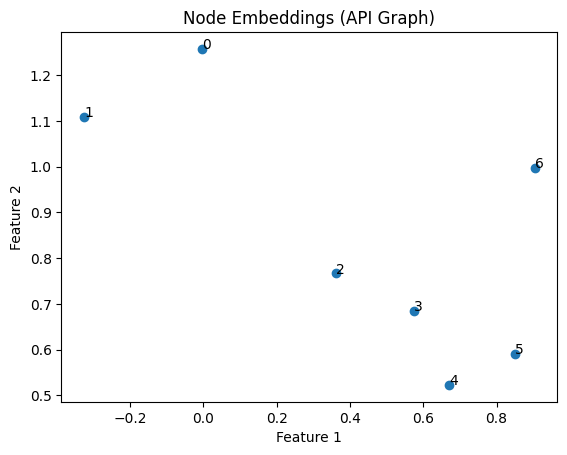

In [6]:
with torch.no_grad():
    embeddings = model.conv1(data.x, data.edge_index)

embeddings = embeddings.numpy()

plt.scatter(embeddings[:,0], embeddings[:,1])

for i in range(len(embeddings)):
    plt.text(embeddings[i,0], embeddings[i,1], str(i))

plt.title("Node Embeddings (API Graph)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()